# 04 - Results Analysis and Visualization
Generate publication-quality figures for the CVPR paper.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np; import pandas as pd
import matplotlib.pyplot as plt; import seaborn as sns
import warnings, os; warnings.filterwarnings("ignore")
from src.svc import SVC
from src.asvc import ASVC
from src.utils import *
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 150, "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12})
CMAP = plt.cm.tab10
os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../results/tables", exist_ok=True)
print("Ready.")
datasets = generate_synthetic_datasets()
X_iris, y_iris, _ = load_uci_iris()
X_iris_2d = standardize(PCA(n_components=2).fit_transform(X_iris))

Ready.


## Figure 1: SVC on Two Moons at Different q

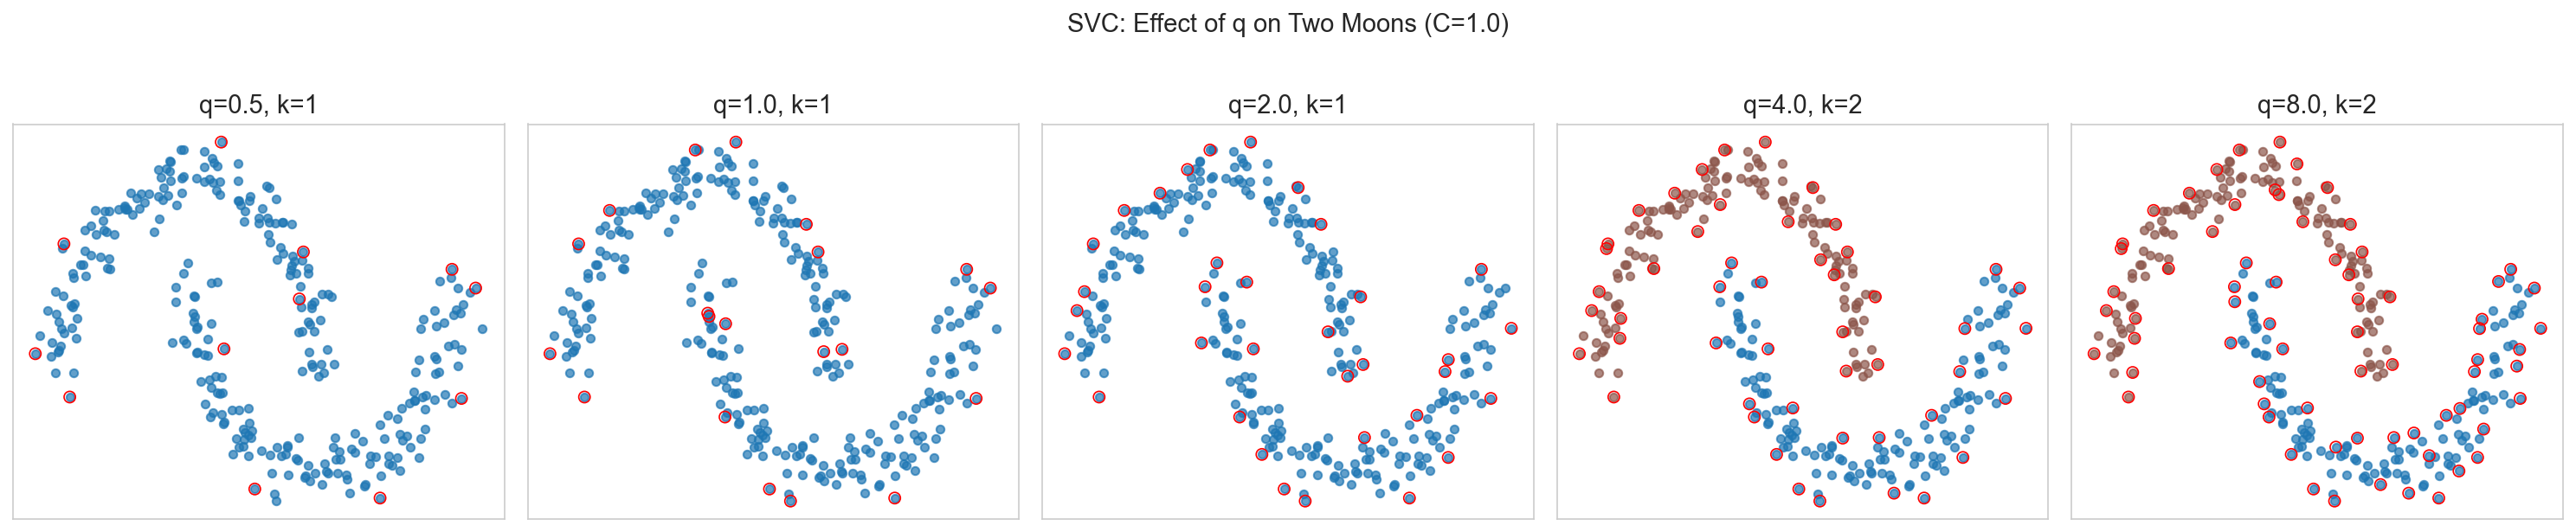

In [2]:
X, y = datasets["TwoMoons"]
qs = [0.5, 1.0, 2.0, 4.0, 8.0]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, q in enumerate(qs):
    svc = SVC(q=q, C=1.0, n_sample_points=30).fit(X)
    ax = axes[i]; ul = np.unique(svc.labels_)
    colors = CMAP(np.linspace(0, 1, max(len(ul), 3)))
    for j, lab in enumerate(ul):
        ax.scatter(X[svc.labels_==lab,0], X[svc.labels_==lab,1], c=[colors[j]], s=20, alpha=0.7)
    ax.scatter(X[svc.sv_mask_,0], X[svc.sv_mask_,1], fc="none", ec="red", s=40, lw=0.8)
    ax.set_title(f"q={q}, k={len(ul)}"); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("SVC: Effect of q on Two Moons (C=1.0)", fontsize=14, y=1.02)
plt.tight_layout(); plt.savefig("../results/figures/fig1_q_effect.png", dpi=200, bbox_inches="tight"); plt.show()

## Figure 2: Method Comparison Bar Chart

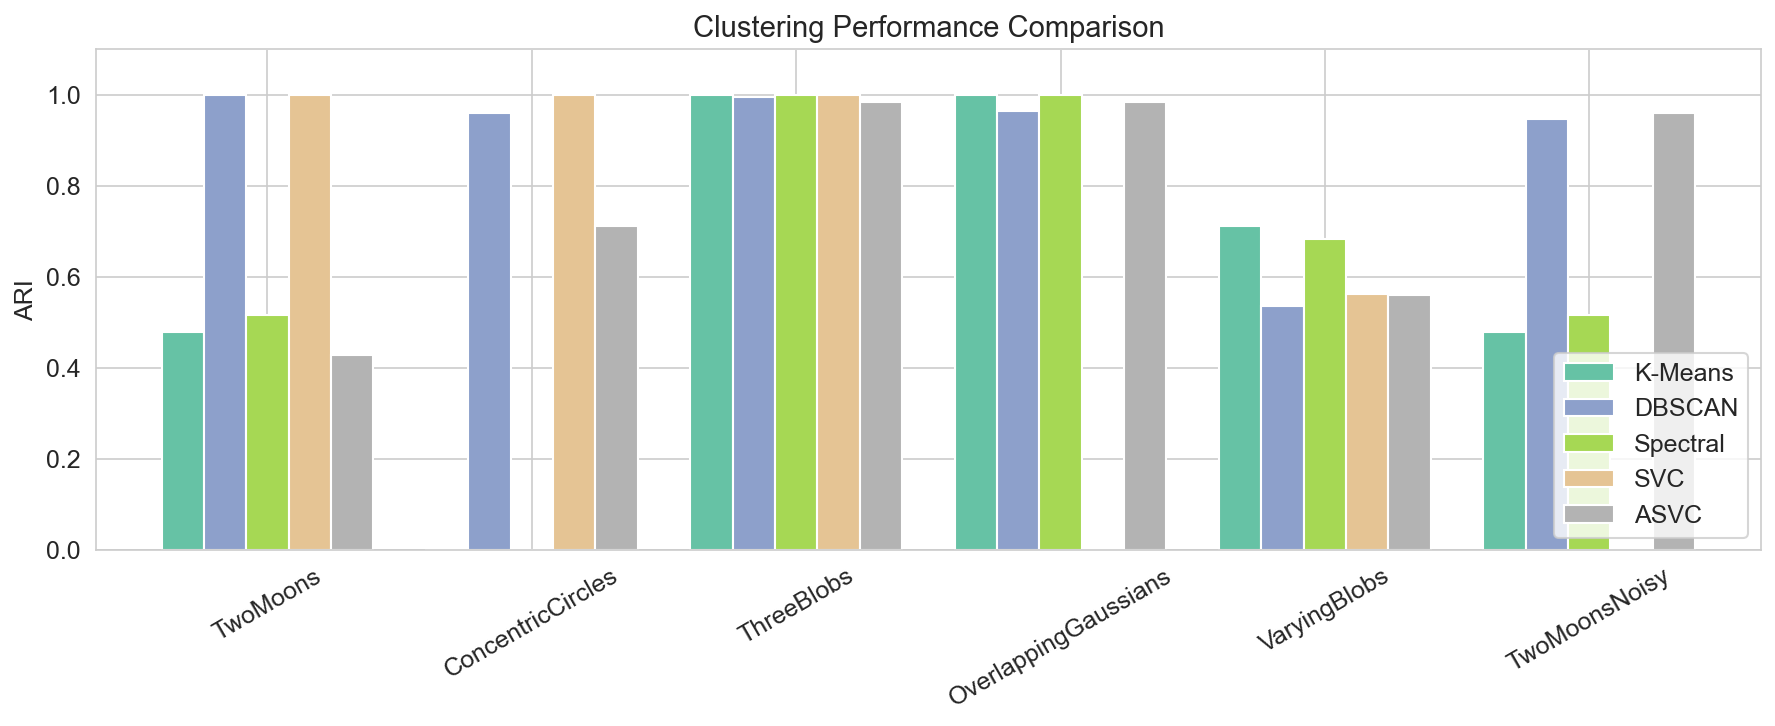

In [3]:
methods = {
    "K-Means": lambda X, k: KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X),
    "DBSCAN": lambda X, k: DBSCAN(eps=0.3, min_samples=5).fit_predict(X),
    "Spectral": lambda X, k: SpectralClustering(n_clusters=k, affinity="rbf", random_state=42).fit_predict(X),
    "SVC": lambda X, k: SVC(q=4.5, C=1.0, n_sample_points=30).fit_predict(X),
    "ASVC": lambda X, k: ASVC(nu=0.02, q="auto", q_search_n_trials=10, random_state=42).fit_predict(X),
}
bar = {}
for name, (Xd, yd) in datasets.items():
    k = len(np.unique(yd)); bar[name] = {}
    for mn, fn in methods.items():
        try: bar[name][mn] = clustering_metrics(yd, fn(Xd, k))["ARI"]
        except: bar[name][mn] = 0
df_bar = pd.DataFrame(bar).T
ax = df_bar.plot(kind="bar", figsize=(12, 5), colormap="Set2", width=0.8)
ax.set_ylabel("ARI"); ax.set_title("Clustering Performance Comparison")
ax.legend(loc="lower right"); ax.set_ylim(0, 1.1)
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig("../results/figures/fig2_comparison_bars.png", dpi=200, bbox_inches="tight"); plt.show()


## Figure 3: Iris Clustering

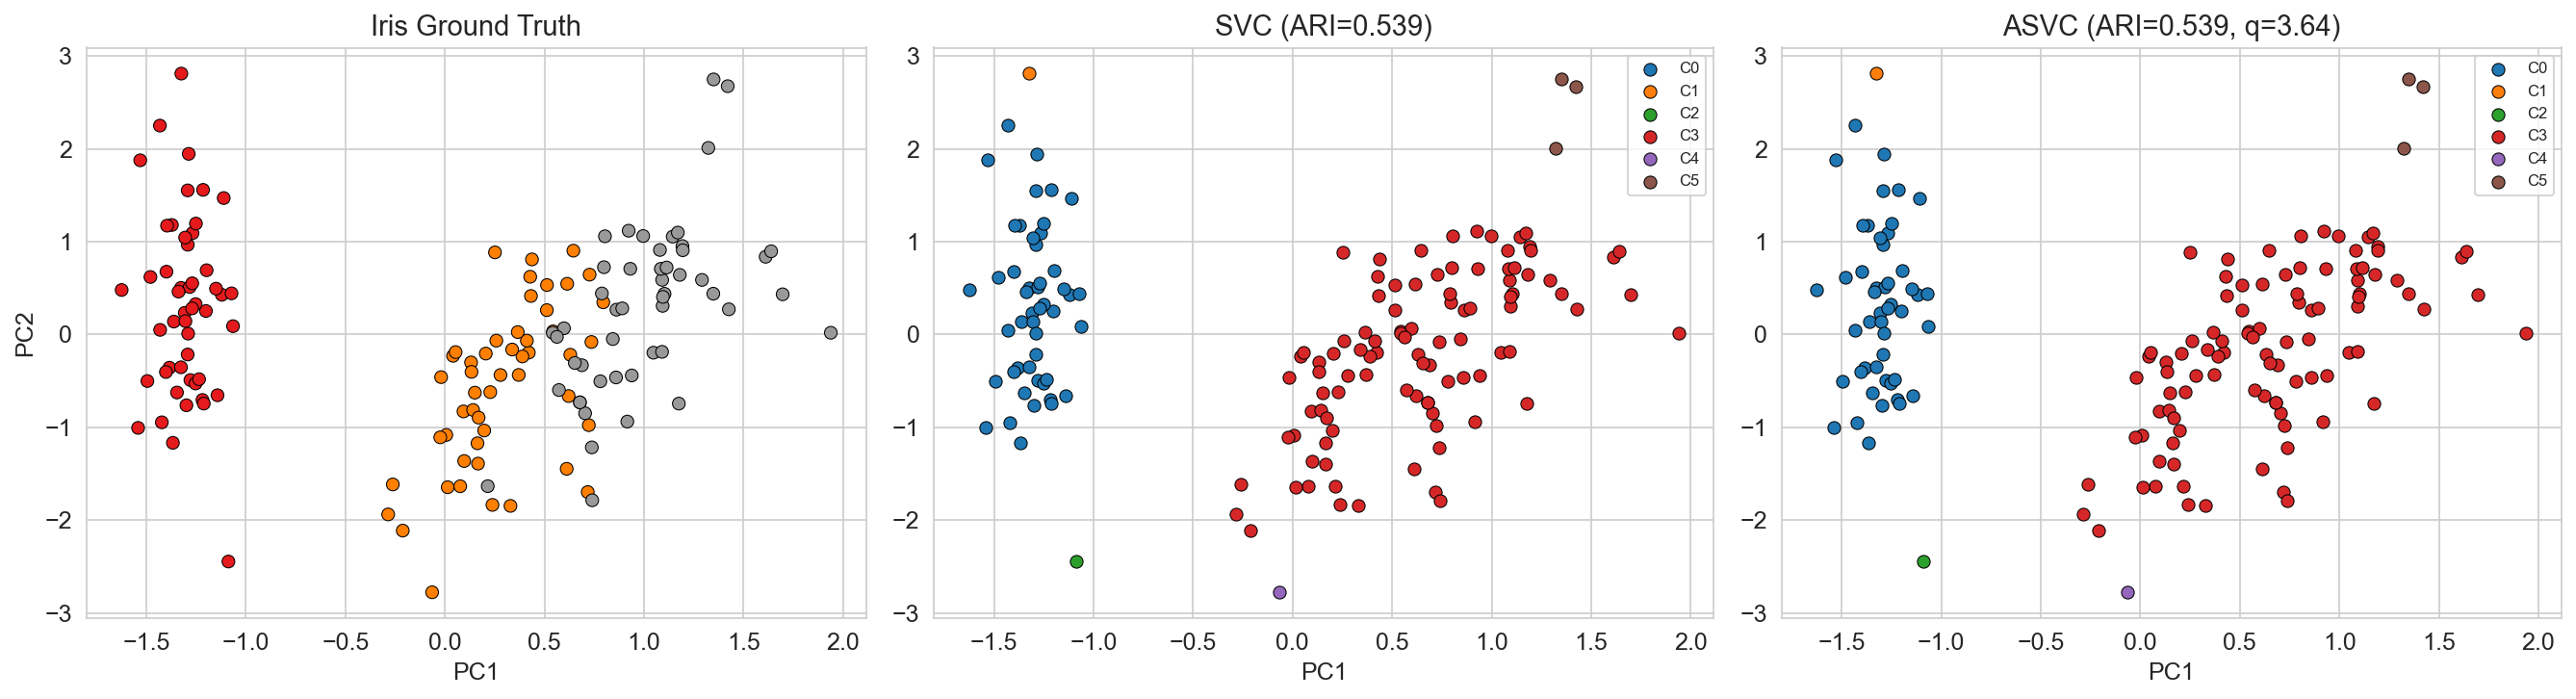

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(X_iris_2d[:,0], X_iris_2d[:,1], c=y_iris, cmap="Set1", s=40, ec="k", lw=0.5)
axes[0].set_title("Iris Ground Truth"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
svc_ir = SVC(q=4.2, C=0.55, n_sample_points=30).fit(X_iris_2d)
for lab in np.unique(svc_ir.labels_):
    m = svc_ir.labels_ == lab
    axes[1].scatter(X_iris_2d[m,0], X_iris_2d[m,1], s=40, ec="k", lw=0.5, label=f"C{lab}")
ari_svc = clustering_metrics(y_iris, svc_ir.labels_)["ARI"]
axes[1].set_title(f"SVC (ARI={ari_svc:.3f})"); axes[1].set_xlabel("PC1"); axes[1].legend(fontsize=8)
asvc_ir = ASVC(nu=0.02, q="auto", q_search_n_trials=10, random_state=42).fit(X_iris_2d)
for lab in np.unique(asvc_ir.labels_):
    m = asvc_ir.labels_ == lab
    axes[2].scatter(X_iris_2d[m,0], X_iris_2d[m,1], s=40, ec="k", lw=0.5, label=f"C{lab}")
ari_asvc = clustering_metrics(y_iris, asvc_ir.labels_)["ARI"]
axes[2].set_title(f"ASVC (ARI={ari_asvc:.3f}, q={asvc_ir.q_used_:.2f})"); axes[2].set_xlabel("PC1"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig("../results/figures/fig3_iris.png", dpi=200, bbox_inches="tight"); plt.show()


## Summary Table

In [5]:
rows = []
for name in ["TwoMoons", "ConcentricCircles", "ThreeBlobs", "OverlappingGaussians", "TwoMoonsNoisy"]:
    Xd, yd = datasets[name]
    svc = SVC(q=4.5, C=1.0, n_sample_points=30).fit(Xd)
    ms = clustering_metrics(yd, svc.labels_)
    rows.append({"Dataset": name, "Method": "SVC", "ARI": f"{ms['ARI']:.3f}", "NMI": f"{ms['NMI']:.3f}", "n_SV": int(svc.sv_mask_.sum()), "n_BSV": int(svc.bsv_mask_.sum())})
    asvc = ASVC(nu=0.02, q="auto", q_search_n_trials=10, random_state=42).fit(Xd)
    ma = clustering_metrics(yd, asvc.labels_)
    rows.append({"Dataset": name, "Method": "ASVC", "ARI": f"{ma['ARI']:.3f}", "NMI": f"{ma['NMI']:.3f}", "n_SV": int(asvc.sv_mask_.sum()), "n_BSV": int(asvc.bsv_mask_.sum())})
df = pd.DataFrame(rows); print(df.to_string(index=False))
df.to_csv("../results/tables/summary_table.csv", index=False)
print("\nAll figures and tables saved to ../results/")


             Dataset Method   ARI   NMI  n_SV  n_BSV
            TwoMoons    SVC 1.000 1.000    53      0
            TwoMoons   ASVC 0.428 0.604   113      0
   ConcentricCircles    SVC 1.000 1.000    75      0
   ConcentricCircles   ASVC 0.711 0.703   118      0
          ThreeBlobs    SVC 1.000 1.000    20      0
          ThreeBlobs   ASVC 0.985 0.975    91      0
OverlappingGaussians    SVC 0.000 0.000    46      0
OverlappingGaussians   ASVC 0.985 0.975    90      0
       TwoMoonsNoisy    SVC 0.000 0.000    72      0
       TwoMoonsNoisy   ASVC 0.960 0.922   107      0

All figures and tables saved to ../results/
